# De Grote Bassie en Adriaan Raket van The Sparrow


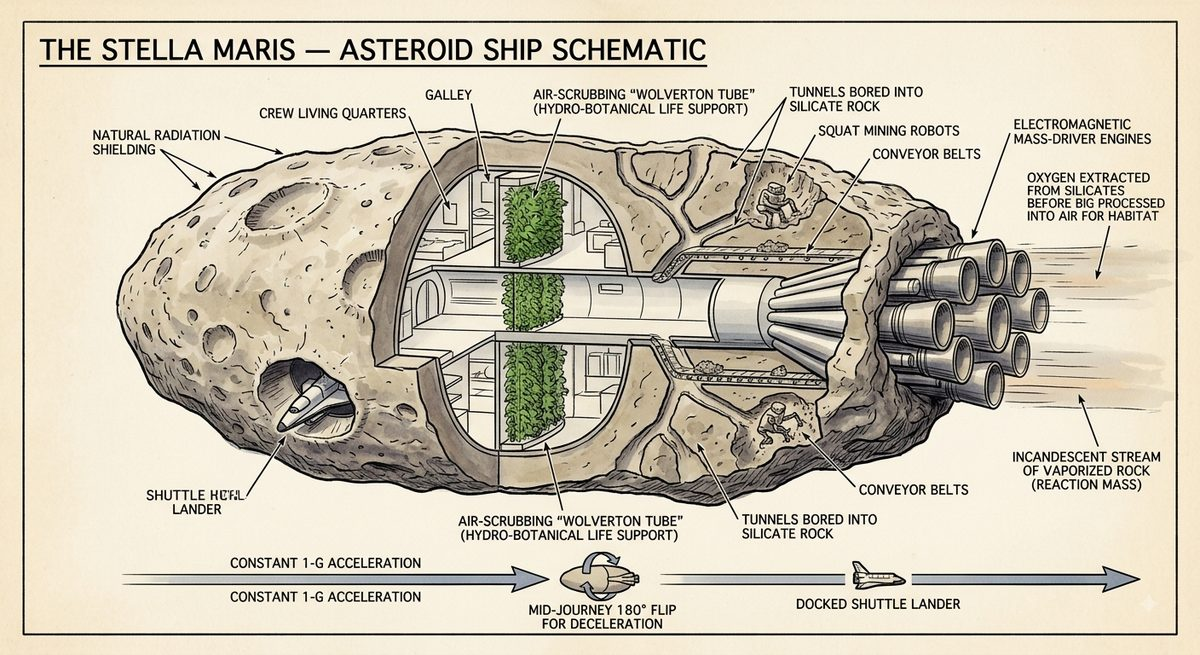


# Snelheid

Snelheid schrijven we als $\beta = v/c$ waar $c$ is lichtsnelheid

$$1\,g = 9.80665\ \mathrm{m/s^2} = 1.0323\ \mathrm{lj/jr^2}$$

Dus, zonder relativiteit ga je na 1 jaar ongeveer $c$


## Formules

**1 · Newton**

$$\beta \approx g\,t$$

- $\beta = v/c$
- $g$ = versnelling van het schip: 1 g = 1.03 lj/jr² ≈ 1
- $t$ = tijd sinds vertrek, gemeten op aarde (jaren)

Constante stuwkracht → snelheid groeit lineair. Prima tot ~0.5 c.

**2 · Relativistisch**

$$\beta(t) = \frac{g t}{\sqrt{1 + (g t)^2}}$$

- $gt$ = teller = de impuls per kg massa ($\gamma\beta$) — dié groeit lineair, voor altijd
- $\sqrt{1+(gt)^2}$ = $\gamma$, de lorentzfactor: hoeveel trager jouw klok loopt
  dan die op aarde ($\gamma = 1/\sqrt{1-\beta^2}$)

Snelheid = impuls gedeeld door $\gamma$.

**3 · Piek uit de afstand (flip-and-burn)**

$$
\gamma_\mathrm{piek} = 1 + \frac{g D}{2}, \qquad
\beta_\mathrm{piek} = \sqrt{1 - 1/\gamma_\mathrm{piek}^2}
$$

- $D$ = totale reisafstand in lichtjaren (Alpha Centauri: 4.37 lj)
- $\gamma_\mathrm{piek}$, $\beta_\mathrm{piek}$ = lorentzfactor en snelheid op het
  omkeerpunt, het snelste moment van de reis (tweede formule = formule voor $\gamma$
  omgekeerd: van $\gamma$ terug naar $\beta$)

Hoogste snelheid = op het omkeerpunt, na afstand $D/2$.

**4 · Reistijd uit de afstand**

$$t_\mathrm{totaal} = \sqrt{D^2 + \frac{4D}{g}}$$

- $t_\mathrm{totaal}$ = totale reistijd volgens de aardklok (jaren)

Bewijs: afstand = integraal van formule 2: $x(t) = \left(\sqrt{1+(gt)^2}-1\right)/g$.
Eis $x = D/2$ op het omkeerpunt, los $t$ op: $t_\mathrm{half} = \sqrt{D/g + D^2/4}$.
Maal 2, klaar. Checks: kleine $D$ → $2\sqrt{D/g}$ (Newton); grote $D$ → $D$ (lichttijd).
Alpha Centauri: $\sqrt{19.1 + 16.9} = \sqrt{36.0} = 6.0$ jr (die ronde 6 is toeval).

**5 · Scheepstijd**

$$\tau = \frac{2}{g}\,\mathrm{artanh}(\beta_\mathrm{piek})$$

- $\tau$ = totale reistijd volgens de scheepsklok (jaren)
- artanh = inverse van tanh

Onderweg loopt de scheepsklok $\gamma\times$ trager dan de aardklok; dit is daarvan
de netto som over de hele reis.


In [21]:
import numpy as np

g = 1.0323  # 1 g in lj/jr^2 (c = 1)


def newton(t):
    """Formule 1: beta = g*t (Newtoniaans, geen limiet op c)."""
    return g * t


def relativistisch(t, a=g):
    """Formule 2: beta = a*t / sqrt(1 + (a*t)^2)."""
    at = a * np.asarray(t)
    return at / np.sqrt(1.0 + at**2)


def piek(D, a=g):
    """Formule 3: (gamma, beta) op het omkeerpunt, uit reisafstand D in lj."""
    gamma = 1.0 + a * D / 2.0
    return gamma, np.sqrt(1.0 - 1.0 / gamma**2)


def reistijd(D, a=g):
    """Formule 4: totale reistijd volgens de aardklok, in jaren."""
    return np.sqrt(D**2 + 4.0 * D / a)


def scheepstijd(D, a=g):
    """Formule 5: totale reistijd volgens de scheepsklok, in jaren."""
    return 2.0 * np.arctanh(piek(D, a)[1]) / a

## Invullen

Formules 1 en 2 op een paar tijdstippen:


In [22]:
print("t (jr)   1 Newton   2 Relativistisch")
for jaar in [0.5, 1.0, 2.0, 3.0]:
    print(f"{jaar:4.1f}     {newton(jaar):.2f} c     {relativistisch(jaar):.2f} c")

t (jr)   1 Newton   2 Relativistisch
 0.5     0.52 c     0.46 c
 1.0     1.03 c     0.72 c
 2.0     2.06 c     0.90 c
 3.0     3.10 c     0.95 c


Formules 3–5 voor Alpha Centauri:


In [23]:
D = 4.37  # lj

gamma_piek, beta_piek = piek(D)
print(f"beta_piek   = {beta_piek:.2f} c   (gamma = {gamma_piek:.2f})")
print(f"aardtijd    = {reistijd(D):.2f} jr")
print(f"scheepstijd = {scheepstijd(D):.2f} jr")

beta_piek   = 0.95 c   (gamma = 3.26)
aardtijd    = 6.00 jr
scheepstijd = 3.58 jr


Hele reis in beeld: formule 2 heen, spiegelbeeld terug. Newton alleen de heenweg.


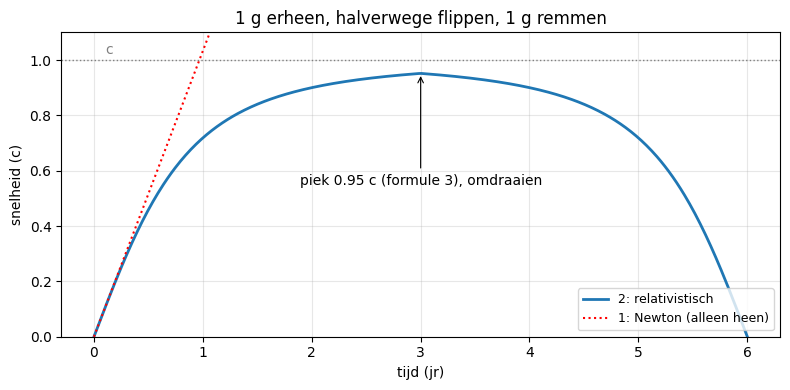

In [24]:
import matplotlib.pyplot as plt

t_half = reistijd(D) / 2.0  # jr; helft van de reis, uit formule 4 — niks hardcoded
t = np.linspace(0.0, 2.0 * t_half, 500)
t_brand = np.minimum(t, 2.0 * t_half - t)  # tijd sinds vertrek / tot aankomst

plt.figure(figsize=(8, 4))
plt.plot(t, relativistisch(t_brand), lw=2, label="2: relativistisch")
t_acc = np.linspace(0.0, t_half, 250)
plt.plot(t_acc, newton(t_acc), ls=":", color="red", lw=1.5, label="1: Newton (alleen heen)")
plt.axhline(1.0, ls=":", lw=1, color="gray")
plt.text(0.1, 1.02, "c", color="gray")
plt.annotate(
    "piek 0.95 c (formule 3), omdraaien",
    (t_half, 0.952),
    (t_half, 0.55),
    ha="center",
    arrowprops={"arrowstyle": "->", "lw": 0.8},
)
plt.xlabel("tijd (jr)")
plt.ylabel("snelheid (c)")
plt.title("1 g erheen, halverwege flippen, 1 g remmen")
plt.ylim(0, 1.1)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Boost in je slaap

Stel: 6 van de 24 uur op 2 g, de rest op 1 g. Gemiddeld per dag:

$$\bar g = \frac{18 \cdot 1 + 6 \cdot 2}{24}\,g = 1.25\,g$$

De dagwissel middelt over een reis van jaren netjes uit → gewoon $\bar g$ invullen in formules 3–5.


In [25]:
print("schema                  gem. g   aardtijd   scheepstijd   piek")
for label, uren_2g in [("alleen 1 g", 0), ("6 u/dag op 2 g", 6), ("8 u/dag op 2 g (boek)", 8)]:
    factor = (24 + uren_2g) / 24.0
    a = g * factor
    _, beta_p = piek(D, a)
    print(
        f"{label:22}  {factor:.2f}     {reistijd(D, a):.2f} jr    "
        f"{scheepstijd(D, a):.2f} jr      {beta_p:.3f} c"
    )

schema                  gem. g   aardtijd   scheepstijd   piek
alleen 1 g              1.00     6.00 jr    3.58 jr      0.952 c
6 u/dag op 2 g          1.25     5.71 jr    3.12 jr      0.965 c
8 u/dag op 2 g (boek)   1.33     5.64 jr    3.00 jr      0.968 c


Samengevat: eerste jaar bijna Newton, daarna vlakt het af. 0.7 c na 1 jr,
0.9 c na 2 jr, piek 0.95 c na 3 jr. Dan spiegelbeeld omlaag. Totaal 6 jr. c haal je nooit.

Slaap-boost: 6 u/dag op 2 g = 1.25 g gemiddeld (1.33 is pas bij 8 u). Winst: ~0.3 aardjaar
en ~0.5 scheepsjaar. Mager rendement voor elke nacht dubbele zwaartekracht.


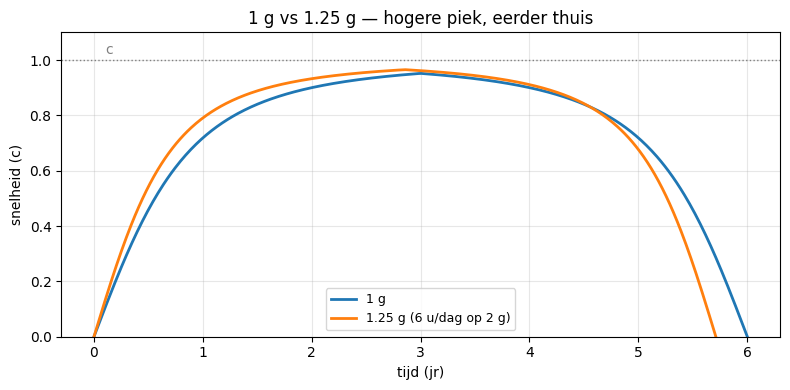

In [26]:
plt.figure(figsize=(8, 4))
for label, a in [("1 g", g), ("1.25 g (6 u/dag op 2 g)", 1.25 * g)]:
    t_half = reistijd(D, a) / 2.0
    t = np.linspace(0.0, 2.0 * t_half, 500)
    t_brand = np.minimum(t, 2.0 * t_half - t)
    plt.plot(t, relativistisch(t_brand, a), lw=2, label=label)

plt.axhline(1.0, ls=":", lw=1, color="gray")
plt.text(0.1, 1.02, "c", color="gray")
plt.xlabel("tijd (jr)")
plt.ylabel("snelheid (c)")
plt.title("1 g vs 1.25 g — hogere piek, eerder thuis")
plt.ylim(0, 1.1)
plt.legend(loc="lower center", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()